In [1]:
!pip install pandas numpy matplotlib seaborn
!pip install scikit-learn nltk wordcloud joblib


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


                                              0.0/1.6 MB ? eta -:--:--
                                              0.0/1.6 MB ? eta -:--:--
     -                                        0.1/1.6 MB 1.1 MB/s eta 0:00:02
     ----                                     0.2/1.6 MB 1.7 MB/s eta 0:00:01
     --------                                 0.3/1.6 MB 2.1 MB/s eta 0:00:01
     -----------                              0.5/1.6 MB 2.3 MB/s eta 0:00:01
     ---------------                          0.6/1.6 MB 2.3 MB/s eta 0:00:01
     ------------------                       0.7/1.6 MB 2.5 MB/s eta 0:00:01
     ---------------------                    0.8/1.6 MB 2.5 MB/s eta 0:00:01
     -------------------------                1.0/1.6 MB 2.6 MB/s eta 0:00:01
     ----------------------------             1.1/1.6 MB 2.6 MB/s eta 0:00:01
     -------------------------------          1.2/1.6 MB 2.6 MB/s eta 0:00:01
     -----------------------------------      1.4/1.6 MB 2.6 MB/s eta 0:00:01



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

df = pd.read_csv('twitter_training.csv',
                 header=None,
                 names=['id', 'entity', 'sentiment', 'text'])

print("Shape:", df.shape)
print("\nfirst 5 rows:")
print(df.head())
print("\nSentiment counts:")
print(df['sentiment'].value_counts())

Shape: (74682, 4)

first 5 rows:
     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Sentiment counts:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91969\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91969\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\91969\AppData\Roaming\nltk_data...


All libraries imported successfully!


Dataset shape after cleaning: (61121, 4)

Sentiment counts:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


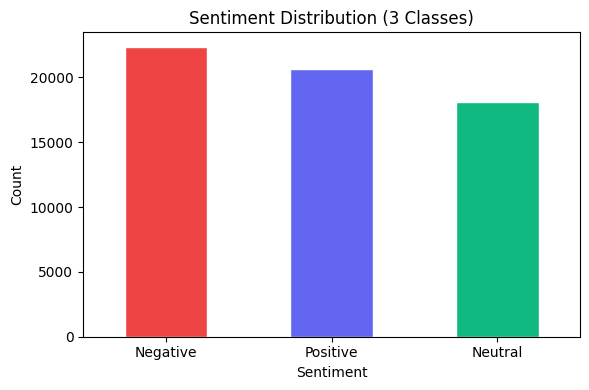

Done!


In [4]:
# Step 4: Clean Dataset

# Remove Irrelevant class
df = df[df['sentiment'] != 'Irrelevant']

# Remove missing values
df = df.dropna(subset=['text'])
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
print("\nSentiment counts:")
print(df['sentiment'].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
colors = ['#ef4444', '#6366f1', '#10b981']
df['sentiment'].value_counts().plot(
    kind='bar', color=colors, edgecolor='white', width=0.5
)
plt.title('Sentiment Distribution (3 Classes)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Done!")

In [5]:
# Step 5: Text Preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_tweet(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(tokens)

# Test the function
sample = "@john This game is AMAZING!!! #bestgame https://t.co/abc"
print("Before:", sample)
print("After :", preprocess_tweet(sample))

# Apply to full dataset
print("\nProcessing all tweets... please wait")
df['clean_text'] = df['text'].apply(preprocess_tweet)
print("Done!")
print("\nSample cleaned tweet:")
print(df['clean_text'][0])

Before: @john This game is AMAZING!!! #bestgame https://t.co/abc
After : game amazing bestgame

Processing all tweets... please wait
Done!

Sample cleaned tweet:
getting borderland murder


In [6]:
# Step 6: Train Test Split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Total samples  :", len(df))
print("Training set   :", len(X_train))
print("Testing set    :", len(X_test))
print("\nTraining distribution:")
print(y_train.value_counts())
print("\nTesting distribution:")
print(y_test.value_counts())
print("\nDone!")

Total samples  : 61121
Training set   : 48896
Testing set    : 12225

Training distribution:
sentiment
Negative    17886
Positive    16524
Neutral     14486
Name: count, dtype: int64

Testing distribution:
sentiment
Negative    4472
Positive    4131
Neutral     3622
Name: count, dtype: int64

Done!


In [7]:
# Step 7: TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.90
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print("Vocabulary size :", len(tfidf.vocabulary_))
print("Training matrix :", X_train_vec.shape)
print("Testing matrix  :", X_test_vec.shape)
print("\nDone!")

Vocabulary size : 15000
Training matrix : (48896, 15000)
Testing matrix  : (12225, 15000)

Done!


In [9]:
# Step 8: Train Logistic Regression Model

model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

print("Training model... please wait")
model.fit(X_train_vec, y_train)
print("Model trained successfully!")

# Top words per class
feature_names = tfidf.get_feature_names_out()

for i, cls in enumerate(model.classes_):
    coefs = model.coef_[i]
    top_idx = coefs.argsort()[-8:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f"\nTop words for {cls}:")
    print(" ", ", ".join(top_words))

Training model... please wait
Model trained successfully!

Top words for Negative:
  fix, suck, boring, worst, fifa, glitch, hate, trash

Top words for Neutral:
  earned, check, commission, latest, alot, ranked, panic, article

Top words for Positive:
  love, excited, best, dope, fun, beautiful, thanks, nice


       MODEL EVALUATION REPORT
  Accuracy  : 80.54%
  F1-Score  : 80.54%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84      4472
     Neutral       0.75      0.76      0.76      3622
    Positive       0.82      0.81      0.81      4131

    accuracy                           0.81     12225
   macro avg       0.80      0.80      0.80     12225
weighted avg       0.81      0.81      0.81     12225



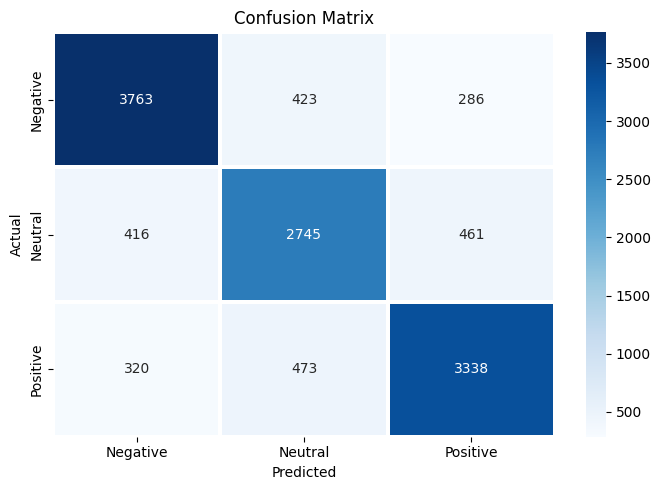

Done!


In [10]:
# Step 9: Model Evaluation

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("       MODEL EVALUATION REPORT")
print("=" * 45)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred,
     labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'],
            linewidths=1.5, linecolor='white')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("Done!")

In [11]:
# Step 10: Predict New Tweets

def predict_sentiment(text):
    clean = preprocess_tweet(text)
    vec = tfidf.transform([clean])
    prediction = model.predict(vec)[0]
    probability = model.predict_proba(vec)[0]
    confidence = round(max(probability) * 100, 1)
    return prediction, confidence

# Test with your own sentences
test_tweets = [
    "I absolutely love this game! Best update ever!",
    "This is the worst product. Total waste of money.",
    "The company announced new features today.",
    "Feeling so happy and excited!",
    "Hate this so much. Terrible experience.",
    "New update released for the app."
]

print("=" * 55)
print("         SENTIMENT PREDICTIONS")
print("=" * 55)
for tweet in test_tweets:
    pred, conf = predict_sentiment(tweet)
    emoji = "😊" if pred=="Positive" else "😞" if pred=="Negative" else "😐"
    print(f"\nTweet : {tweet[:50]}")
    print(f"Result: {emoji} {pred} ({conf}% confidence)")
    print("-" * 55)

         SENTIMENT PREDICTIONS

Tweet : I absolutely love this game! Best update ever!
Result: 😊 Positive (90.8% confidence)
-------------------------------------------------------

Tweet : This is the worst product. Total waste of money.
Result: 😞 Negative (96.8% confidence)
-------------------------------------------------------

Tweet : The company announced new features today.
Result: 😊 Positive (48.9% confidence)
-------------------------------------------------------

Tweet : Feeling so happy and excited!
Result: 😊 Positive (98.5% confidence)
-------------------------------------------------------

Tweet : Hate this so much. Terrible experience.
Result: 😞 Negative (72.5% confidence)
-------------------------------------------------------

Tweet : New update released for the app.
Result: 😞 Negative (62.4% confidence)
-------------------------------------------------------


In [12]:
# Step 11: Save Model

import joblib

joblib.dump(model, 'twitter_sentiment_model.pkl')
joblib.dump(tfidf, 'twitter_tfidf_vectorizer.pkl')

print("Files saved successfully!")
print("  -> twitter_sentiment_model.pkl")
print("  -> twitter_tfidf_vectorizer.pkl")

# Final Summary
print("\n" + "=" * 50)
print("     MINOR PROJECT - FINAL SUMMARY")
print("=" * 50)
print("  Project    : Sentiment Analysis on Text Data")
print("  Dataset    : Twitter Sentiment (Kaggle)")
print("  Total Data : 61,121 tweets")
print("  Classes    : Positive, Negative, Neutral")
print("  Algorithm  : Logistic Regression")
print("  Features   : TF-IDF (15,000 features)")
print("  Split      : 80% Train / 20% Test")
print("  Accuracy   : 80.54%")
print("  F1-Score   : 80.54%")
print("=" * 50)
print("\nProject Complete!")

Files saved successfully!
  -> twitter_sentiment_model.pkl
  -> twitter_tfidf_vectorizer.pkl

     MINOR PROJECT - FINAL SUMMARY
  Project    : Sentiment Analysis on Text Data
  Dataset    : Twitter Sentiment (Kaggle)
  Total Data : 61,121 tweets
  Classes    : Positive, Negative, Neutral
  Algorithm  : Logistic Regression
  Features   : TF-IDF (15,000 features)
  Split      : 80% Train / 20% Test
  Accuracy   : 80.54%
  F1-Score   : 80.54%

Project Complete!
